In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [35]:
column_names = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']
df = pd.read_excel('/content/glass.xlsx', header=None, names=column_names, skiprows=20)
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type


In [7]:
df.head()

,Prepare a model for glass classification using Random Forest
0,Data Description:
1,RI : refractive index
2,Na: Sodium (unit measurement: weight percent i...
3,Mg: Magnesium
4,AI: Aluminum


In [8]:
df.shape

(19, 1)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 1 columns):
 #   Column                                                        Non-Null Count  Dtype 
---  ------                                                        --------------  ----- 
 0   Prepare a model for glass classification using Random Forest  18 non-null     object
dtypes: object(1)
memory usage: 284.0+ bytes


In [10]:
df.columns

Index(['Prepare a model for glass classification using Random Forest'], dtype='object')

In [11]:
df.isnull().sum()

,0
Prepare a model for glass classification using Random Forest,1


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,Prepare a model for glass classification using Random Forest
count,18
unique,18
top,Data Description:
freq,1


In [16]:
df['Type'].value_counts()


,count
Type,


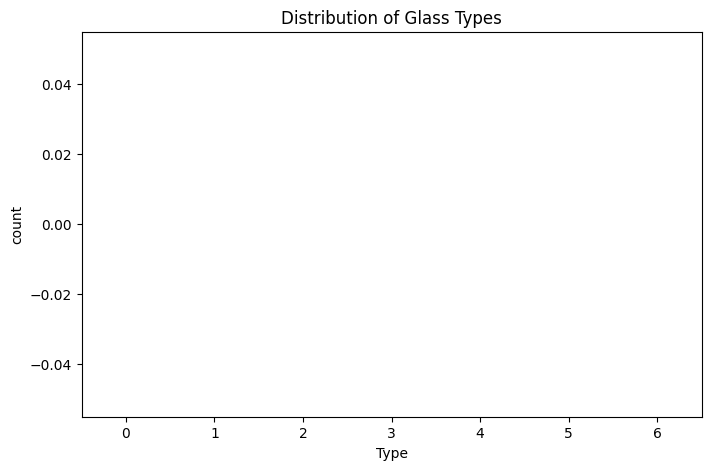

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x='Type', data=df)
plt.title('Distribution of Glass Types')
plt.show()

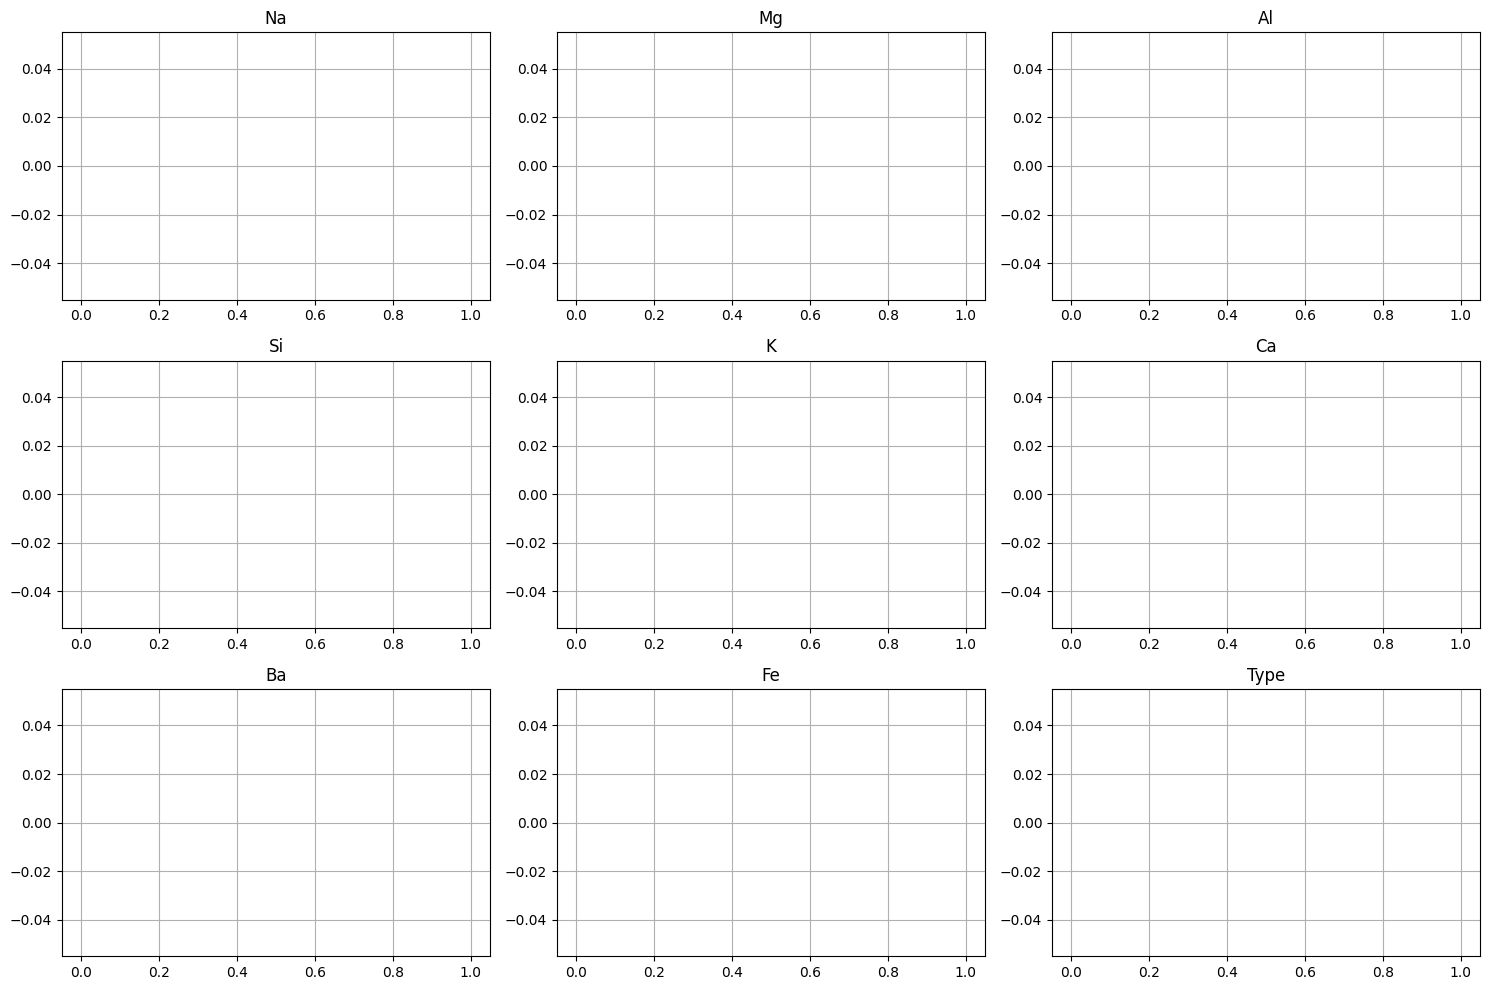

In [18]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

In [19]:
num_cols = df.select_dtypes(include=np.number).columns

In [25]:
num_cols = df.select_dtypes(include='number').columns
print(num_cols)

Index(['Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')


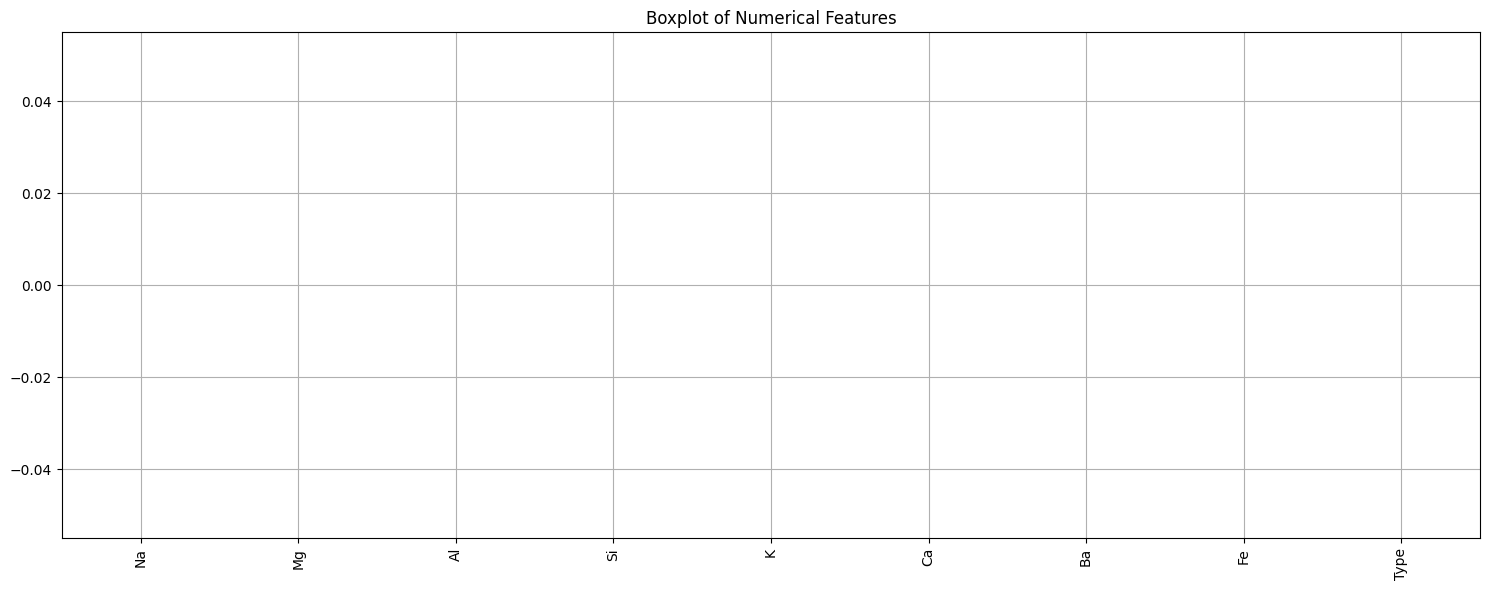

In [26]:
plt.figure(figsize=(15, 6))

df[num_cols].boxplot()

plt.xticks(rotation=90)
plt.title('Boxplot of Numerical Features')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


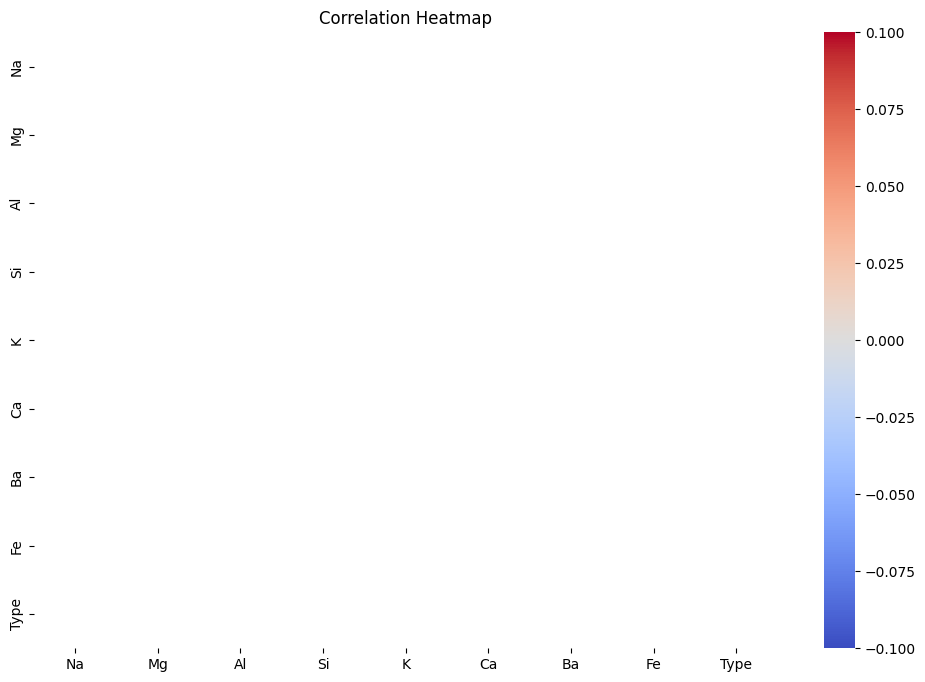

In [27]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [28]:
df['Type'].value_counts()

,count
Type,


In [29]:
X = df.drop('Type', axis=1)
y = df['Type']

In [30]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20, 9)
Target shape: (20,)


In [31]:
X.isnull().sum()

,0
RI,1
Na,20
Mg,20
Al,20
Si,20
K,20
Ca,20
Ba,20
Fe,20


In [32]:
print(y.value_counts())

Series([], Name: count, dtype: int64)


In [33]:
print(y.value_counts(normalize=True) * 100)

Series([], Name: proportion, dtype: float64)


In [37]:
print(df['Type'].isnull().sum())

0


In [38]:
df[df['Type'].isnull()]

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type


In [39]:
df = df.dropna(subset=['Type']).copy()

In [40]:
print("Missing Type:", df['Type'].isnull().sum())
print("Shape:", df.shape)

Missing Type: 0
Shape: (0, 10)


In [41]:
X = df.drop('Type', axis=1)
y = df['Type']

In [42]:
print(X.isnull().sum())

RI    0
Na    0
Mg    0
Al    0
Si    0
K     0
Ca    0
Ba    0
Fe    0
dtype: int64


In [45]:
import pandas as pd
import numpy as np

df = pd.read_excel("/content/glass.xlsx", sheet_name="glass")

print(df.shape)
print(df.isnull().sum())

(214, 10)
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


In [46]:
print(df['Type'].value_counts())
print("Missing Type:", df['Type'].isnull().sum())

Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64
Missing Type: 0


In [47]:
X = df.drop(columns=['Type'])
y = df['Type']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Missing in X:", X.isnull().sum().sum())
print("Missing in y:", y.isnull().sum())

X shape: (214, 9)
y shape: (214,)
Missing in X: 0
Missing in y: 0


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (171, 9)
X_test: (43, 9)
y_train: (171,)
y_test: (43,)


In [49]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

In [50]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [51]:
y_pred = rf_model.predict(X_test)

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))

Accuracy : 0.7441860465116279
Precision: 0.7499254621347645
Recall   : 0.7441860465116279
F1 Score : 0.739695962951777


In [53]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.69      0.79      0.73        14
           2       0.77      0.67      0.71        15
           3       0.50      0.33      0.40         3
           5       0.75      1.00      0.86         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.74        43
   macro avg       0.73      0.77      0.74        43
weighted avg       0.75      0.74      0.74        43



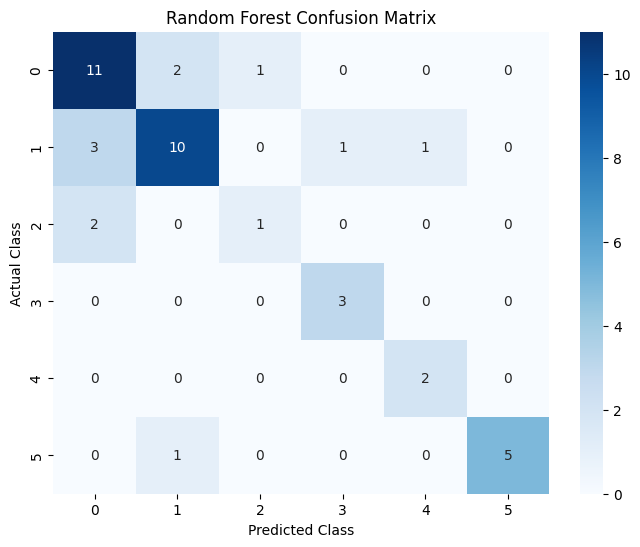

In [54]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [55]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

Mg    0.185550
Ca    0.144214
K     0.135500
Na    0.125744
Al    0.124430
RI    0.105561
Si    0.082195
Ba    0.078174
Fe    0.018633
dtype: float64


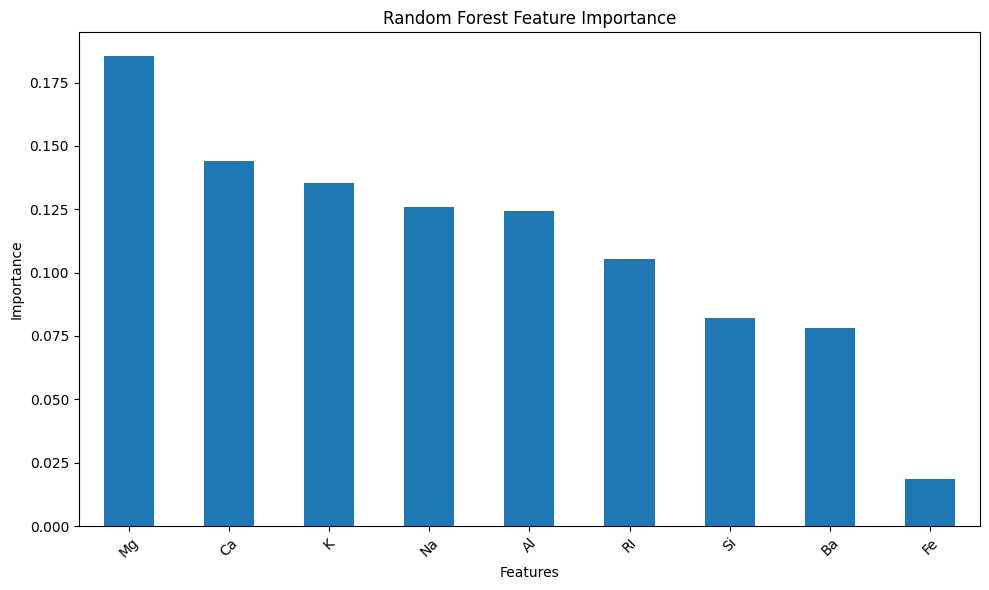

In [56]:
plt.figure(figsize=(10, 6))

feature_importance.plot(kind='bar')

plt.title('Random Forest Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

| Metric             |    Score |
| ------------------ | -------: |
| Accuracy           | **0.74** |
| Weighted Precision | **0.75** |
| Weighted Recall    | **0.74** |
| Weighted F1-score  | **0.74** |


In [58]:
#Import Bagging
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

In [59]:
#Create the Bagging model
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)

In [60]:
#Train bagging
bagging_model.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=100, random_state=42)

In [61]:
#Predict
bagging_pred = bagging_model.predict(X_test)

In [62]:
#Evaluate bagging
print("Bagging Accuracy :", accuracy_score(y_test, bagging_pred))
print("Bagging Precision:", precision_score(y_test, bagging_pred, average='weighted'))
print("Bagging Recall   :", recall_score(y_test, bagging_pred, average='weighted'))
print("Bagging F1 Score :", f1_score(y_test, bagging_pred, average='weighted'))

Bagging Accuracy : 0.813953488372093
Bagging Precision: 0.8225232132208875
Bagging Recall   : 0.813953488372093
Bagging F1 Score : 0.811869365598315


In [63]:
#Classification report
print(classification_report(y_test, bagging_pred))

              precision    recall  f1-score   support

           1       0.80      0.86      0.83        14
           2       0.85      0.73      0.79        15
           3       1.00      0.67      0.80         3
           5       0.67      0.67      0.67         3
           6       0.67      1.00      0.80         2
           7       0.86      1.00      0.92         6

    accuracy                           0.81        43
   macro avg       0.81      0.82      0.80        43
weighted avg       0.82      0.81      0.81        43



In [64]:
#Import AdaBoost
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

In [65]:
#Create the boosting model
boost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42
)

In [66]:
#Train
boost_model.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   n_estimators=100, random_state=42)

In [67]:
#Predict
boost_pred = boost_model.predict(X_test)

In [68]:
#Evaluate
print("Boosting Accuracy :", accuracy_score(y_test, boost_pred))
print("Boosting Precision:", precision_score(y_test, boost_pred, average='weighted'))
print("Boosting Recall   :", recall_score(y_test, boost_pred, average='weighted'))
print("Boosting F1 Score :", f1_score(y_test, boost_pred, average='weighted'))

Boosting Accuracy : 0.3953488372093023
Boosting Precision: 0.46666666666666656
Boosting Recall   : 0.3953488372093023
Boosting F1 Score : 0.3638166894664842


In [69]:
#Classification report
print(classification_report(y_test, boost_pred))

              precision    recall  f1-score   support

           1       0.67      0.14      0.24        14
           2       0.36      0.60      0.45        15
           3       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         3
           6       0.67      1.00      0.80         2
           7       0.67      0.67      0.67         6

    accuracy                           0.40        43
   macro avg       0.39      0.40      0.36        43
weighted avg       0.47      0.40      0.36        43



In [70]:
#Create comparison table
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Bagging', 'Boosting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, bagging_pred),
        accuracy_score(y_test, boost_pred)
    ],
    'Precision': [
        precision_score(y_test, y_pred, average='weighted'),
        precision_score(y_test, bagging_pred, average='weighted'),
        precision_score(y_test, boost_pred, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, bagging_pred, average='weighted'),
        recall_score(y_test, boost_pred, average='weighted')
    ],
    'F1 Score': [
        f1_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, bagging_pred, average='weighted'),
        f1_score(y_test, boost_pred, average='weighted')
    ]
})



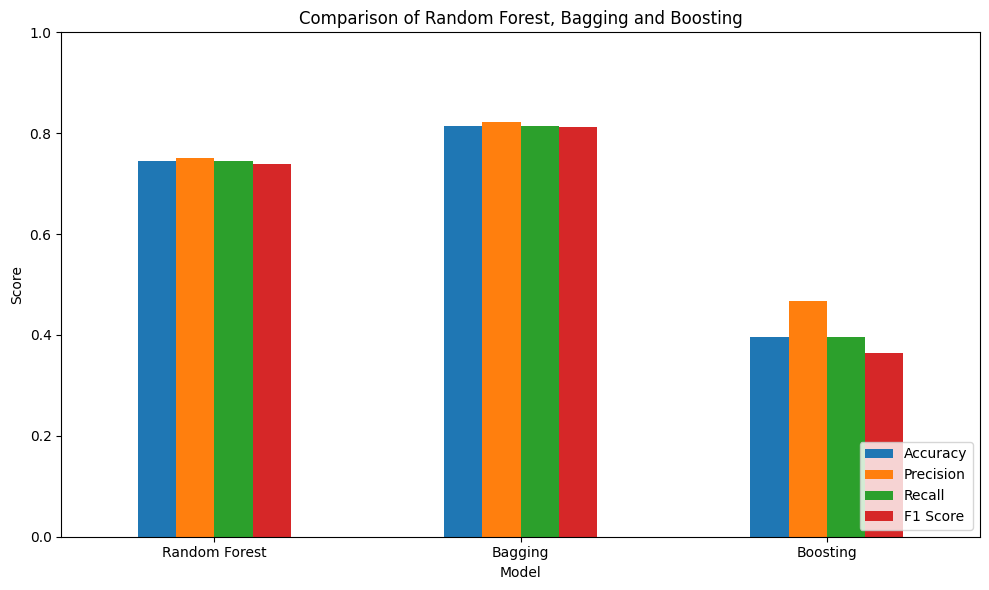

In [71]:
#Visual comparision
comparison.set_index('Model').plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Comparison of Random Forest, Bagging and Boosting')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [72]:
#Check which model performed best
best_model = comparison.loc[
    comparison['Accuracy'].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model         Bagging
Accuracy     0.813953
Precision    0.822523
Recall       0.813953
F1 Score     0.811869
Name: 1, dtype: object


#Additional Notes:

1. Explain Bagging and Boosting methods. How is it different from each other.
Bagging (Bootstrap Aggregating) is an ensemble machine learning technique that combines multiple models to improve prediction performance and reduce overfitting.

Advantages of Bagging
Reduces overfitting.
Improves model stability.
Reduces variance.
Works well with decision trees.
Can improve prediction accuracy.

2. Explain how to handle imbalance in the data.
Imbalanced data occurs when some classes have significantly more observations than other classes. If not handled properly, the model may become biased toward the majority class.

The following methods can be used to handle imbalanced data:

1)Oversampling: Increase the number of samples in minority classes. Techniques such as Random Oversampling and SMOTE can be used.

2)Undersampling: Reduce the number of samples from the majority class to balance the classes.
